#### Import Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

#### Checking GPU

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU: []


#### Dataset path

In [3]:
DATASET_PATH = r"D:\datasets\glaucoma"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "validation")
test_dir = os.path.join(DATASET_PATH, "test")

print(train_dir)

D:\datasets\glaucoma\train


#### Image settings

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 8

In [28]:
print(train_data.samples)
print(val_data.samples)
print(test_data.samples)

4500
564
562


#### Image preprocessing

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

#### Load Training Dataset

In [6]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 4500 images belonging to 2 classes.


#### Load Validation dataset

In [7]:
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 564 images belonging to 2 classes.


#### Load test dataset

In [8]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 562 images belonging to 2 classes.


In [9]:
print(train_data.class_indices)

{'glaucoma': 0, 'normal': 1}


#### Visualize images

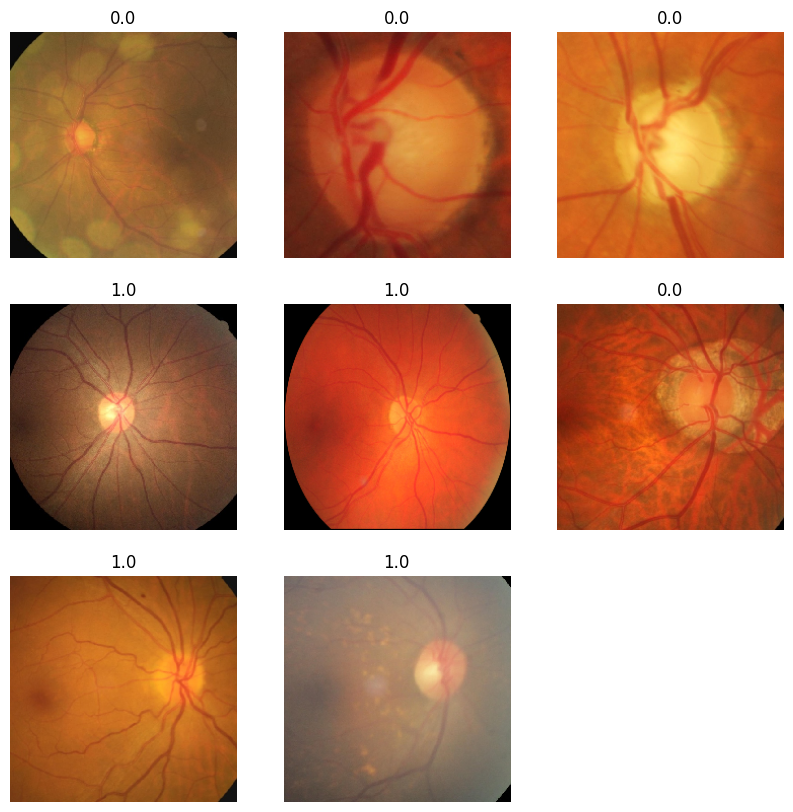

In [10]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.show()

In [15]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

#### Loading the base model

In [16]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


#### freeze the base model

In [18]:
base_model.trainable = False

#### Build the classifier head

In [20]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(1, activation="sigmoid")(x)

#### Create the full model

In [22]:
model = models.Model(inputs=base_model.input, outputs=output)

#### Compile the model

In [23]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#### View the architecture

#### Train the DenseNet121 model

In [25]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 225s 359ms/step - accuracy: 0.7273 - loss: 0.5378 - val_accuracy: 0.7926 - val_loss: 0.4436
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 159s 282ms/step - accuracy: 0.8104 - loss: 0.4263 - val_accuracy: 0.8138 - val_loss: 0.4000
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 154s 273ms/step - accuracy: 0.8220 - loss: 0.3928 - val_accuracy: 0.8351 - val_loss: 0.3779
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 154s 274ms/step - accuracy: 0.8353 - loss: 0.3686 - val_accuracy: 0.8067 - val_loss: 0.3964
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 153s 271ms/step - accuracy: 0.8420 - loss: 0.3513 - val_accuracy: 0.8440 - val_loss: 0.3620
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 153s 272ms/step - accuracy: 0.8516 - loss: 0.3348 - val_accuracy: 0.7660 - val_loss: 0.4273
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 154s 273ms/step - accuracy: 0.8547 - loss: 0.3203 - val_accuracy: 0.8617 - val_loss: 0.3316
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 154s 273ms/step - accuracy: 0.8553 -

#### Evaluating on test data

In [26]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test accuracy:", test_accuracy)

71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 572ms/step - accuracy: 0.8452 - loss: 0.3406
Test accuracy: 0.8451957106590271


#### Saving the model

In [27]:
model.save(r"D:\glaucoma_models\glaucoma_densenet121.h5")

#### ROC-AUC

In [29]:
from sklearn.metrics import roc_curve, auc
import numpy as np

In [30]:
y_pred = model.predict(test_data)
y_true = test_data.classes

71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 335ms/step


In [31]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.924810982636998


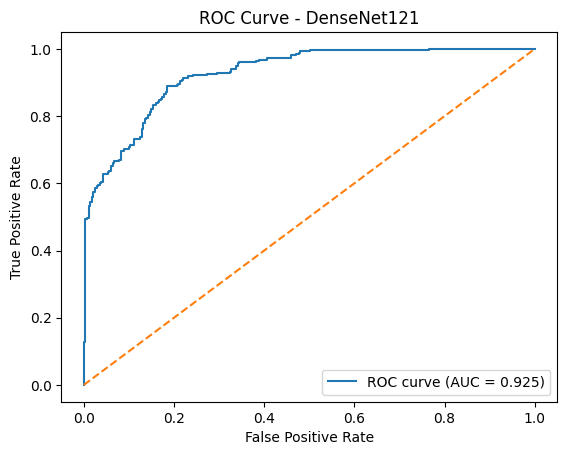

In [32]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DenseNet121")
plt.legend()

plt.show()

In [33]:
print(train_data.class_indices)

{'glaucoma': 0, 'normal': 1}


In [34]:
y_pred_glaucoma = 1 - y_pred

In [35]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_glaucoma)
roc_auc = auc(fpr, tpr)

print("AUC (Glaucoma detection):", roc_auc)

AUC (Glaucoma detection): 0.07518901736300199


In [36]:
print(min(y_pred), max(y_pred))

[1.8523426e-06] [0.99999875]


## Model 2

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [12]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4500 images belonging to 2 classes.
Found 564 images belonging to 2 classes.
Found 562 images belonging to 2 classes.


#### Importing EfficientNet

In [13]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

In [14]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

In [15]:
base_model.trainable = False

In [16]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(1, activation="sigmoid")(x)

In [17]:
model_eff = models.Model(inputs=base_model.input, outputs=output)

#### Compile the model

In [18]:
model_eff.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#### Training

In [19]:
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 363s 618ms/step - accuracy: 0.7656 - loss: 0.4727 - val_accuracy: 0.8369 - val_loss: 0.3803
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 201s 357ms/step - accuracy: 0.8256 - loss: 0.3802 - val_accuracy: 0.8457 - val_loss: 0.3446
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 78s 138ms/step - accuracy: 0.8502 - loss: 0.3368 - val_accuracy: 0.8475 - val_loss: 0.3321
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 71s 125ms/step - accuracy: 0.8536 - loss: 0.3226 - val_accuracy: 0.8599 - val_loss: 0.3301
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 70s 124ms/step - accuracy: 0.8656 - loss: 0.3042 - val_accuracy: 0.8440 - val_loss: 0.3527
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 71s 126ms/step - accuracy: 0.8762 - loss: 0.2861 - val_accuracy: 0.8617 - val_loss: 0.2957
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 71s 125ms/step - accuracy: 0.8738 - loss: 0.2848 - val_accuracy: 0.8635 - val_loss: 0.2974
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 71s 126ms/step - accuracy: 0.8767 - loss:

In [20]:
test_loss, test_accuracy = model_eff.evaluate(test_data)

print("EfficientNet Test accuracy:", test_accuracy)

71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 288ms/step - accuracy: 0.8594 - loss: 0.3096
EfficientNet Test accuracy: 0.8594306111335754


In [21]:
y_pred_eff = model_eff.predict(test_data)
y_true = test_data.classes

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_eff)
roc_auc_eff = auc(fpr, tpr)

print("EfficientNet AUC:", roc_auc_eff)

71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 187ms/step
EfficientNet AUC: 0.9388938843226403


In [22]:
model_eff.save(r"D:\glaucoma_models\glaucoma_efficientnet.h5")